<a href="https://colab.research.google.com/github/Sunay-2103/SunayMukherjee_23FE10CSE00636/blob/main/Test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('/content/seeds_dataset.csv')

Preprocessing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length_of_ kernel        210 non-null    float64
 4   Width_of_kernel          210 non-null    float64
 5   Asymmetry_coefficient    210 non-null    float64
 6   Length_of_kernel_groove  210 non-null    float64
 7   Class_(1, 2, 3)          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [6]:
df.describe()

,Area,Perimeter,Compactness,Length_of_ kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,"Class_(1, 2, 3)"
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [7]:
df.head()

,Area,Perimeter,Compactness,Length_of_ kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,"Class_(1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [46]:
df.dropna(inplace = True)

In [48]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Length_of_ kernel,0
Width_of_kernel,0
Asymmetry_coefficient,0
Length_of_kernel_groove,0
"Class_(1, 2, 3)",0


In [47]:
df.notnull().sum()

,0
Area,210
Perimeter,210
Compactness,210
Length_of_ kernel,210
Width_of_kernel,210
Asymmetry_coefficient,210
Length_of_kernel_groove,210
"Class_(1, 2, 3)",210


Data Visualization


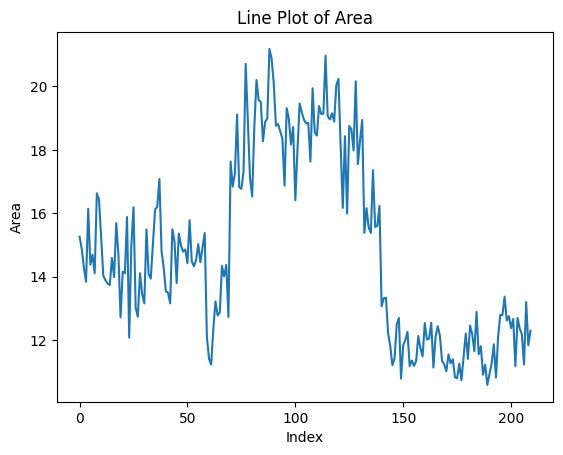

In [39]:
plt.plot(df['Area'])
plt.title('Line Plot of Area')
plt.xlabel('Index')
plt.ylabel('Area')
plt.show()

<Axes: xlabel='Class_(1, 2, 3)'>

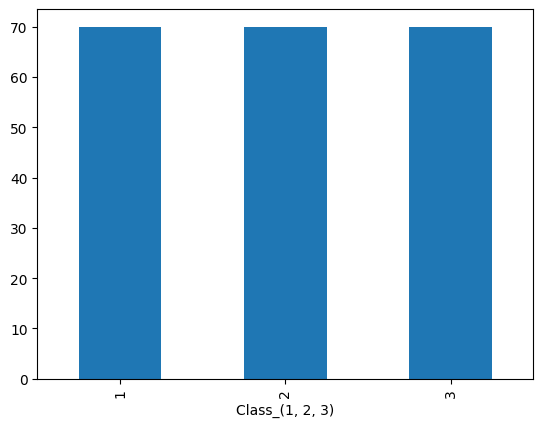

In [43]:
df["Class_(1, 2, 3)"].value_counts().plot(kind="bar")

(array([11., 41., 40., 25., 21., 16., 19., 20.,  9.,  8.]),
 array([4.899 , 5.0766, 5.2542, 5.4318, 5.6094, 5.787 , 5.9646, 6.1422,
        6.3198, 6.4974, 6.675 ]),
 <BarContainer object of 10 artists>)

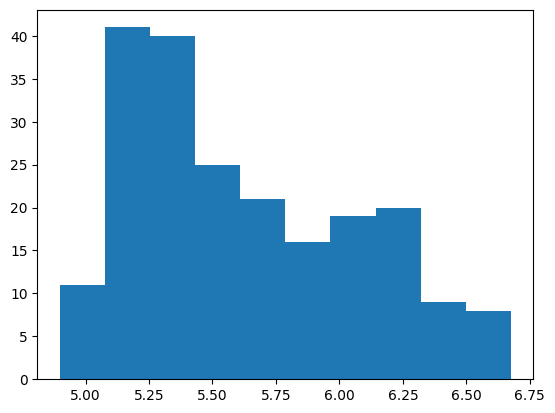

In [45]:
plt.hist(df['Length_of_ kernel'])

Train test split

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop('Class_(1, 2, 3)',axis=1)
y = df['Class_(1, 2, 3)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [11]:
X.head()

,Area,Perimeter,Compactness,Length_of_ kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


## Training a Decision Tree Model

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dtree = DecisionTreeClassifier(criterion='gini',max_depth=None)

In [14]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

## Predictions and Evaluation of Decision Tree


In [15]:
predictions = dtree.predict(X_test)

In [16]:
from sklearn.metrics import classification_report,confusion_matrix

In [17]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           1       0.74      0.85      0.79        20
           2       1.00      0.86      0.92        21
           3       0.86      0.86      0.86        22

    accuracy                           0.86        63
   macro avg       0.87      0.86      0.86        63
weighted avg       0.87      0.86      0.86        63



In [18]:
cm=confusion_matrix(y_test,predictions)
print(cm)
print ("Accuracy of prediction:",round((cm[0,0]+cm[1,1])/cm.sum(),3))

[[17  0  3]
 [ 3 18  0]
 [ 3  0 19]]
Accuracy of prediction: 0.556


## Training the Random Forest model



In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rfc = RandomForestClassifier(n_estimators=600)

In [21]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600)

## Predictions and Evaluation


In [22]:
rfc_pred = rfc.predict(X_test)

In [23]:
cr = classification_report(y_test,predictions)

In [24]:
print(cr)

              precision    recall  f1-score   support

           1       0.74      0.85      0.79        20
           2       1.00      0.86      0.92        21
           3       0.86      0.86      0.86        22

    accuracy                           0.86        63
   macro avg       0.87      0.86      0.86        63
weighted avg       0.87      0.86      0.86        63



In [25]:
cm = confusion_matrix(y_test,rfc_pred)
print(cm)

[[18  0  2]
 [ 1 20  0]
 [ 4  0 18]]
